In this exercise, we develop a model that suggests similar products based on a given item. We utilize `Word2Vec()` to train the model and construct a recommendation system.

Data: [Link](https://www.kaggle.com/datasets/samantas2020/online-retail-xlsx)

Steps to Solve This Exercise
1. Data preprocessing (Download, Handle Missing Value and Split dataset (train set: 90%,test set:10%))
2. Build a representation model for products in the training dataset. (Model, Vocabulary and Training)
3. Visualize word2vec Embeddings
4. Build a function to compute the similarity of products.
5. This result is based on the vector of a single product. What happens if we want to recommend products to a customer based on the products they have previously chosen?

# Data preprocessing

## Data exploration

### Whole dataset

In [4]:
! pip install kagglehub
import os
import kagglehub

path = kagglehub.dataset_download("samantas2020/online-retail-xlsx")
data_file_path = os.path.join(path, 'Online Retail.xlsx')

In [5]:
import pandas as pd

df = pd.read_excel(data_file_path)
display(df.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


! Cautious!!!! Why do we have some negative values here? We need to explore the dataset more

Also, the format of InvoiceDate don't hold for all samples.

In [7]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


### Invoice Number

Nominal. A 6-digit integral number uniquely assigned to each transaction. If this code starts with the letter 'C', it indicates a cancellation. About the codes start with letter 'A', don't really get the meaning of it.

In [8]:
print("We only have int and string value in Invoice Number?", len(list(filter(lambda x: isinstance(x, str), df['InvoiceNo'].unique()))) == len(list(filter(lambda x: not isinstance(x, int), df['InvoiceNo'].unique()))))
print("Number of string starting with letter \'c\'" , len(list(filter(lambda x: isinstance(x, str) and x.startswith('C'), df['InvoiceNo']))))
print("All string without starting with letter \'c\'" ,list(filter(lambda x: isinstance(x, str) and not x.startswith('C'), df['InvoiceNo'])))

We only have int and string value in Invoice Number? True
Number of string starting with letter 'c' 9288
All string without starting with letter 'c' ['A563185', 'A563186', 'A563187']


In [9]:
# Negative unit price
df.loc[df['UnitPrice'].apply(lambda x: x < 0)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [10]:
# InvoiceNo starts with letter 'A'
df.loc[df['InvoiceNo'].apply(lambda x: isinstance(x, str) and x.startswith('A'))]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


As we can see, those sample with InvoiceNo starting with letter 'A' have "Adjust bad debt" , and with negative UnitPrice. So we will drop them

In [11]:
df = df.loc[df['InvoiceNo'].apply(lambda x: isinstance(x, int) or not x.startswith('A'))]

In [12]:
# InvoiceNo starts with letter 'C'
df.loc[df['InvoiceNo'].apply(lambda x: isinstance(x, str) and x.startswith('C'))]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


As i think, the system will consider cancelled invoices are the ones with negative value of quantity. We will check it out.

In [13]:
neg_quant = df.loc[df['Quantity'].apply(lambda x: x <= 0)]
print("Number of samples with negative quantity:",len(neg_quant))
print("Number of samples with negative quantity, and being a number:", len(neg_quant.loc[neg_quant['InvoiceNo'].apply(lambda x: isinstance(x,int))]))
print("Number of samples with negative quantity, and being a string without starting with letter \'C\':", len(neg_quant.loc[neg_quant['InvoiceNo'].apply(lambda x: isinstance(x, str) and not x.startswith('C'))]))
print("Number of samples with negative quantity, and being a string starting with letter \'C\':", len(neg_quant.loc[neg_quant['InvoiceNo'].apply(lambda x: isinstance(x, str) and x.startswith('C'))]))

Number of samples with negative quantity: 10624
Number of samples with negative quantity, and being a number: 1336
Number of samples with negative quantity, and being a string without starting with letter 'C': 0
Number of samples with negative quantity, and being a string starting with letter 'C': 9288


We can conclude that only samples havign InvoiceNo with type string and starting with letter C are the ones that have negatuve quantity.

Also, where are 1336 remaining samples with negative quantity with normal InvoiceNo?

In [14]:
neg_quant_normInvoiceNo = neg_quant.loc[neg_quant.apply(lambda x: isinstance(x['InvoiceNo'],int) and pd.notna(x['Description']), axis = 1)]
neg_quant_normInvoiceNo

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
7313,537032,21275,?,-30,2010-12-03 16:50:00,0.0,NaN,United Kingdom
13217,537425,84968F,check,-20,2010-12-06 15:35:00,0.0,NaN,United Kingdom
13218,537426,84968E,check,-35,2010-12-06 15:36:00,0.0,NaN,United Kingdom
13264,537432,35833G,damages,-43,2010-12-06 16:10:00,0.0,NaN,United Kingdom
21338,538072,22423,faulty,-13,2010-12-09 14:10:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535333,581210,23395,check,-26,2011-12-07 18:36:00,0.0,NaN,United Kingdom
535335,581212,22578,lost,-1050,2011-12-07 18:38:00,0.0,NaN,United Kingdom
535336,581213,22576,check,-30,2011-12-07 18:38:00,0.0,NaN,United Kingdom
536908,581226,23090,missing,-338,2011-12-08 09:56:00,0.0,NaN,United Kingdom


In [15]:
neg_quant_normInvoiceNo['Description'].unique()

array(['?', 'check', 'damages', 'faulty', 'Dotcom sales',
       'reverse 21/5/10 adjustment', 'mouldy, thrown away.', 'counted',
       'Given away', 'Dotcom', 'label mix up', 'samples/damages',
       'thrown away', 'incorrectly made-thrown away.', 'showroom', 'MIA',
       'Dotcom set', 'wrongly sold as sets', 'Amazon sold sets',
       'dotcom sold sets', 'wrongly sold sets', '? sold as sets?',
       '?sold as sets?', 'Thrown away.', 'damages/display',
       'damaged stock', 'broken', 'throw away', 'wrong barcode (22467)',
       'wrong barcode', 'barcode problem', '?lost',
       "thrown away-can't sell.", "thrown away-can't sell", 'damages?',
       're dotcom quick fix.', "Dotcom sold in 6's", 'sold in set?',
       'cracked', 'sold as 22467', 'Damaged',
       'mystery! Only ever imported 1800',
       'MERCHANT CHANDLER CREDIT ERROR, STO', 'POSSIBLE DAMAGES OR LOST?',
       'damaged', 'DAMAGED', 'Display', 'Missing', 'wrong code?',
       'wrong code', 'adjust', 'crushed', 

As this time, I don't see any meaningful information of samples having negative quantity with normal InvoiceNo. So, I will delete them here.

In [16]:
df = df.loc[df.apply(lambda x: x['Quantity'] > 0 or isinstance(x['InvoiceNo'], str), axis = 1)]

I will check out whether the samples with InvoiceNo starting with letter C has the same absolute value with the InvoiceNo number.

In [17]:
# Example
df.loc[df.apply(lambda x: x['CustomerID'] == 14527.0 and x['StockCode'] in [22788, 22469, 22169], axis = 1)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
20174,538012,22469,HEART OF WICKER SMALL,2,2010-12-09 12:32:00,1.65,14527.0,United Kingdom
84996,543454,22788,BROCANTE COAT RACK,1,2011-02-08 12:20:00,9.95,14527.0,United Kingdom
149290,C549288,22788,BROCANTE COAT RACK,-1,2011-04-07 18:06:00,9.95,14527.0,United Kingdom
149291,C549288,22469,HEART OF WICKER SMALL,-1,2011-04-07 18:06:00,1.65,14527.0,United Kingdom
218212,556023,22169,FAMILY ALBUM WHITE PICTURE FRAME,1,2011-06-08 12:21:00,8.50,14527.0,United Kingdom
225875,C556735,22169,FAMILY ALBUM WHITE PICTURE FRAME,-2,2011-06-14 12:01:00,8.50,14527.0,United Kingdom
367212,568875,22469,HEART OF WICKER SMALL,1,2011-09-29 12:23:00,1.65,14527.0,United Kingdom
458956,575855,22169,FAMILY ALBUM WHITE PICTURE FRAME,1,2011-11-11 12:24:00,8.50,14527.0,United Kingdom


As we can see, the quantity of the cancellation invoices don't need to be equal, or even greater than the quantity of same product. So, as i think the invoices are different, that means the cancellation does not come from any original invoice. The cancellation invoices just switch the number of quantity from positive to negative value.

Also, the number in the string does not match with any other invoice, so we will later turn the quantity into positive value for processing task, and the invoiceNo with string value will be treated equally as number value.

In [18]:
is_string_invoice = df['InvoiceNo'].apply(lambda x: isinstance(x, str))
df.loc[is_string_invoice, 'Quantity'] = df.loc[is_string_invoice, 'Quantity'].apply(lambda x: -x)

In [19]:
df.loc[df['InvoiceNo'].apply(lambda x: isinstance(x, str))]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


### Invoice Date

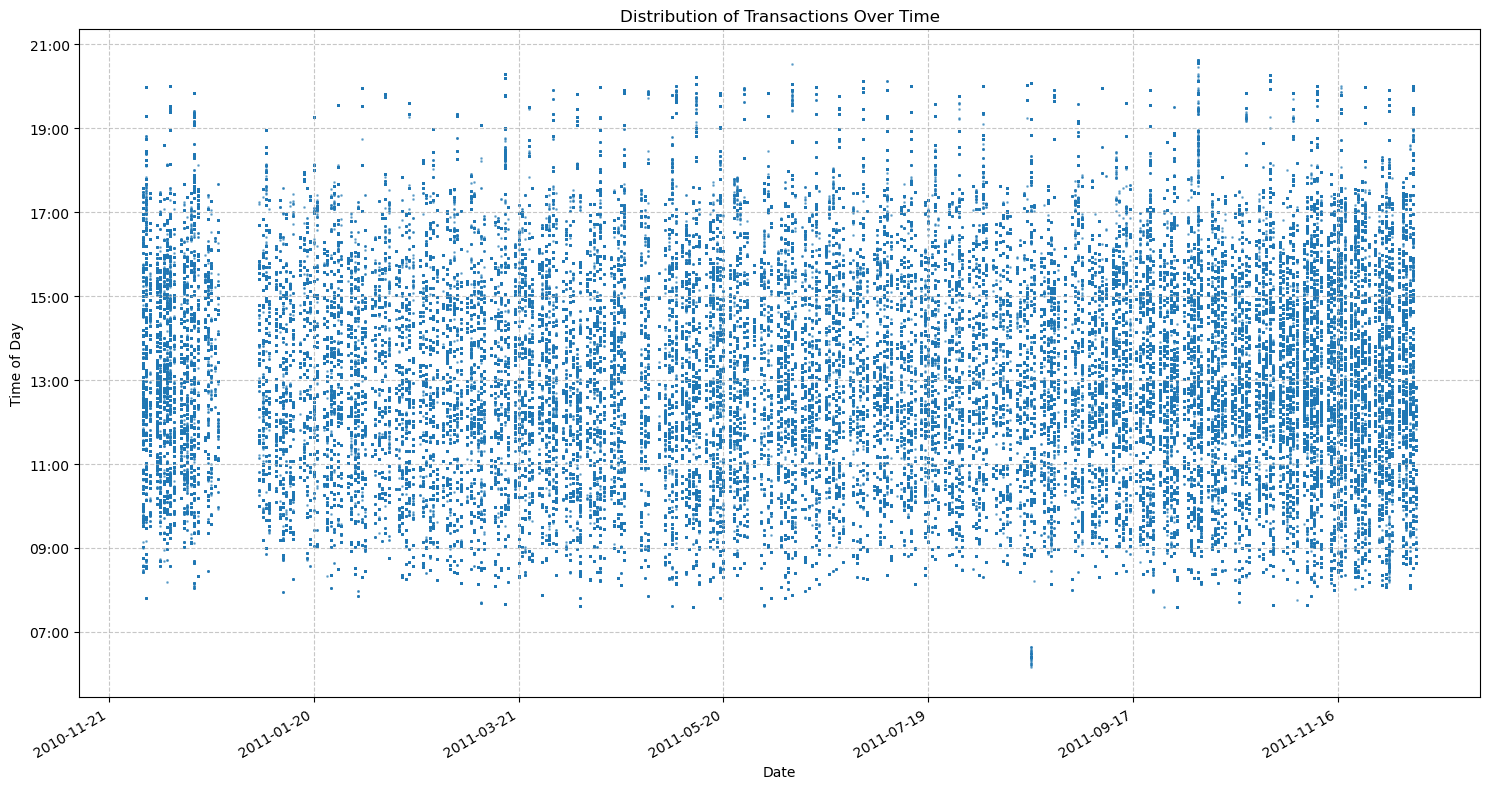

In [20]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

df['transaction_date'] = df['InvoiceDate'].dt.date
df['transaction_time'] = df['InvoiceDate'].dt.time
df['transaction_time_for_plot'] = df['transaction_time'].apply(
    lambda t: datetime.datetime(2000, 1, 1, t.hour, t.minute, t.second)
)

plt.figure(figsize=(15, 8))
plt.scatter(df['transaction_date'], df['transaction_time_for_plot'], alpha=0.5, s=1)

plt.xlabel('Date')
plt.ylabel('Time of Day')
plt.title('Distribution of Transactions Over Time')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=60)) # Every 60 days
plt.gcf().autofmt_xdate()

plt.gca().yaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().yaxis.set_major_locator(mdates.HourLocator(interval=2)) # Every 2 hours

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [21]:
df = df.drop(columns = ['transaction_time_for_plot', 'transaction_time', 'transaction_date'])

### Country

In [22]:
df['Country'].value_counts()

Country
United Kingdom          494139
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


In [23]:
df.loc[df['Country'] == 'Iceland']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
14938,537626,85116,BLACK CANDELABRA T-LIGHT HOLDER,12,2010-12-07 14:57:00,2.10,12347.0,Iceland
14939,537626,22375,AIRLINE BAG VINTAGE JET SET BROWN,4,2010-12-07 14:57:00,4.25,12347.0,Iceland
14940,537626,71477,COLOUR GLASS. STAR T-LIGHT HOLDER,12,2010-12-07 14:57:00,3.25,12347.0,Iceland
14941,537626,22492,MINI PAINT SET VINTAGE,36,2010-12-07 14:57:00,0.65,12347.0,Iceland
14942,537626,22771,CLEAR DRAWER KNOB ACRYLIC EDWARDIAN,12,2010-12-07 14:57:00,1.25,12347.0,Iceland
...,...,...,...,...,...,...,...,...
535010,581180,20719,WOODLAND CHARLOTTE BAG,10,2011-12-07 15:52:00,0.85,12347.0,Iceland
535011,581180,21265,PINK GOOSE FEATHER TREE 60CM,12,2011-12-07 15:52:00,1.95,12347.0,Iceland
535012,581180,23271,CHRISTMAS TABLE SILVER CANDLE SPIKE,16,2011-12-07 15:52:00,0.83,12347.0,Iceland
535013,581180,23506,MINI PLAYING CARDS SPACEBOY,20,2011-12-07 15:52:00,0.42,12347.0,Iceland


I will try to explore whether there are some interesting information hide inside the 'Country' attribute.

After the exploration, i have some thoughts that:
- With countries having low frequency, they most have 1-2 users.
- With countries having higher frequency, they have a lot of users, but the products don't seems to be alike.

I will also drop this collumn

In [24]:
df = df.drop(columns = ['Country'])

## Handle missing values

In [25]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0
...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0


In [26]:
print(f"Number of Nan value in {len(df)} samples with attribute:")
print("InvoiceNo:", len(df.loc[df['InvoiceNo'].isna()]))
print("StockCode:", len(df.loc[df['StockCode'].isna()]))
print("Description:", len(df.loc[df['Description'].isna()]))
print("UnitPrice:", len(df.loc[df['UnitPrice'].isna()]))
print("CustomerID:", len(df.loc[df['CustomerID'].isna()]))

Number of Nan value in 540570 samples with attribute:
InvoiceNo: 0
StockCode: 0
Description: 592
UnitPrice: 0
CustomerID: 133741


### Description

For the NaN description, we will drop those samples, because the number of th em is quite small in terms of the whole number of dataset. ALso, as i explored, the invoices with NaN value in description only have 1 product and Nan CustomerID.

In [27]:
df.loc[df['Description'].isna()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN
...,...,...,...,...,...,...,...
533712,581103,22689,NaN,4,2011-12-07 11:58:00,0.0,NaN
535326,581203,23406,NaN,15,2011-12-07 18:31:00,0.0,NaN
535332,581209,21620,NaN,6,2011-12-07 18:35:00,0.0,NaN
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN


In [28]:
# Example
df.loc[df['InvoiceNo'] == 581103]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
533712,581103,22689,NaN,4,2011-12-07 11:58:00,0.0,NaN


In [29]:
df = df.loc[df['Description'].apply(lambda x: pd.notna(x) and x not in ['adjustment', 'Adjustment', 'returned'])]

### CustomerID

In [30]:
print(f"The percentage of samples having NaN value in CustomerID: {len(df.loc[df['CustomerID'].isna()]) / len(df):.2%}")

The percentage of samples having NaN value in CustomerID: 24.66%


In [31]:
df.loc[df['CustomerID'].isna()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN
1447,536544,21790,VINTAGE SNAP CARDS,9,2010-12-01 14:32:00,1.66,NaN
...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00,4.13,NaN
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00,4.13,NaN
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00,4.96,NaN
541539,581498,85174,S/4 CACTI CANDLES,1,2011-12-09 10:26:00,10.79,NaN


As we can see, the number of samples is quite high, i will treat each invoice with Nan value in customerID having its unique customerID implitcitly, instead of dropping them.That does not means we will assign a customerID value for it, we can think as that we have many customers with Nan CustomerID, and they can only buy one invoice in their whole life :v

### Quantity and UnitPrice

These attributes can have potential information to extract, but i will ignore them this time.

In [32]:
df = df.drop(columns = ['Quantity', 'UnitPrice'])

### StockCode
In StockCode, there are some products thatt have some specific meaning, such as M - Manual, ... I will ignore those products

In [33]:
df.loc[df['StockCode'].apply(lambda x: isinstance(x, str) and len(x) == 1)][['StockCode', 'Description']]

,StockCode,Description
141,D,Discount
2239,M,Manual
2250,M,Manual
5684,M,Manual
6798,M,Manual
...,...,...
531432,M,Manual
533082,M,Manual
534308,M,Manual
538321,M,Manual


In [34]:
df = df.loc[df['StockCode'].apply(lambda x: isinstance(x, int) or len(x) > 1)]

## Train, test split (90/10)

In [35]:
products_per_invoice = df.groupby('InvoiceNo').size()
display(products_per_invoice.describe())

count    23617.000000
mean        22.833044
std         44.589921
min          1.000000
25%          3.000000
50%         12.000000
75%         25.000000
max       1114.000000
dtype: float64

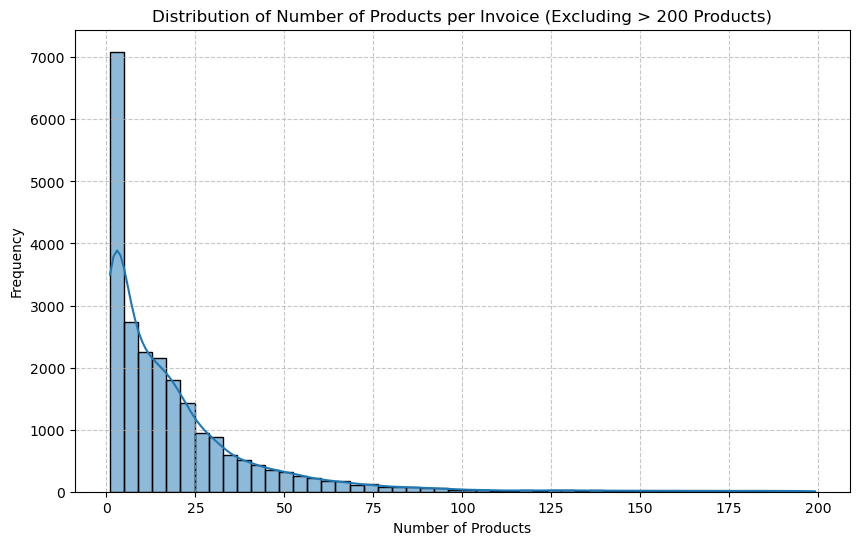

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out invoices with more than 200 products
products_per_invoice_filtered = products_per_invoice[products_per_invoice <= 200]

plt.figure(figsize=(10, 6))
sns.histplot(products_per_invoice_filtered, bins=50, kde=True)
plt.title('Distribution of Number of Products per Invoice (Excluding > 200 Products)')
plt.xlabel('Number of Products')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [37]:
df

,InvoiceNo,StockCode,Description,InvoiceDate,CustomerID
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2010-12-01 08:26:00,17850.0
1,536365,71053,WHITE METAL LANTERN,2010-12-01 08:26:00,17850.0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,2010-12-01 08:26:00,17850.0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,2010-12-01 08:26:00,17850.0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,2010-12-01 08:26:00,17850.0
...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,2011-12-09 12:50:00,12680.0
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,2011-12-09 12:50:00,12680.0
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,2011-12-09 12:50:00,12680.0
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,2011-12-09 12:50:00,12680.0


I will ignore the description from here, and get back to it after the training and testing phase. So, I will create the mapping from the stockcod with the description for easier tracking

In [38]:
mapping_df = df[['StockCode', 'Description']].drop_duplicates(subset=['StockCode'], keep='last')
id_to_description = dict(zip(mapping_df['StockCode'], mapping_df['Description']))

print(f'Number of unique product codes: {len(id_to_description)}')
list(id_to_description.items())[:5]

Number of unique product codes: 3935


[(84854, 'GIRLY PINK TOOL SET'),
 (20957, 'PORCELAIN HANGING BELL SMALL'),
 (82615, 'PINK MARSHMALLOW SCARF KNITTING KIT'),
 ('35271S', 'GOLD PRINT PAPER BAG'),
 (21268, 'VINTAGE BLUE TINSEL REEL')]

In [39]:
# I then concatenate all the products' StockCode with same InvoiceNo into a single strings.
invoice_sequences = df.groupby(['InvoiceNo', 'CustomerID', 'InvoiceDate'], dropna=False)['StockCode'].apply(lambda x: ' '.join(x.astype(str))).reset_index()
invoice_sequences.rename(columns={'StockCode': 'StockCode_List'}, inplace=True)
invoice_sequences = invoice_sequences.sort_values(by='InvoiceDate').reset_index(drop=True)

print(f'Total unique invoices: {len(invoice_sequences)}')
display(invoice_sequences.head())

Total unique invoices: 23660


,InvoiceNo,CustomerID,InvoiceDate,StockCode_List
0,536365,17850.0,2010-12-01 08:26:00,85123A 71053 84406B 84029G 84029E 22752 21730
1,536366,17850.0,2010-12-01 08:28:00,22633 22632
2,536367,13047.0,2010-12-01 08:34:00,84879 22745 22748 22749 22310 84969 22623 2262...
3,536368,13047.0,2010-12-01 08:34:00,22960 22913 22912 22914
4,536369,13047.0,2010-12-01 08:35:00,21756


I will perform the temporal customer split by identifying last invoices for customers and guests, then sampling them until they constitute approximately 10% of total product occurrences as per the instructions.



In [40]:
import numpy as np

# Identify the last invoice for each customer
invoice_sequences['product_count'] = invoice_sequences['StockCode_List'].apply(lambda x: len(x.split()))
invoice_sequences = invoice_sequences.loc[invoice_sequences['product_count'] > 1]
last_invoices_mask = invoice_sequences.groupby('CustomerID')['InvoiceDate'].transform("max") == invoice_sequences['InvoiceDate']
guest_mask = invoice_sequences['CustomerID'].isna()

# Combine masks to identify the sampling pool
pool_mask = (last_invoices_mask & ~guest_mask) | guest_mask
sampling_pool = invoice_sequences[pool_mask].copy()

# Calculate total product occurrences and target (10%)
total_products = invoice_sequences['product_count'].sum()
target_test_size = total_products * 0.10

# Randomly sample from pool until target is reached
sampling_pool = sampling_pool.sample(frac=1, random_state=42)
sampling_pool['cumulative_products'] = sampling_pool['product_count'].cumsum()
test_indices = sampling_pool[sampling_pool['cumulative_products'] <= target_test_size].index

# Define test_set and train_pool
test_set = invoice_sequences.loc[test_indices].copy()
train_pool = invoice_sequences.drop(test_indices).copy()

actual_split_pct = (test_set['product_count'].sum() / total_products) * 100
print(f'Target product count: {target_test_size:.0f}')
print(f'Actual test product count: {test_set["product_count"].sum():.0f} ({actual_split_pct:.2f}%)')
print(f'Test set size: {len(test_set)} invoices')
print(f'Train pool size: {len(train_pool)} invoices')
display(test_set.head())

Target product count: 53568
Actual test product count: 53550 (10.00%)
Test set size: 1379 invoices
Train pool size: 18680 invoices


,InvoiceNo,CustomerID,InvoiceDate,StockCode_List,product_count
13317,562024,NaN,2011-08-01 16:07:00,21407 21454 21471 21506 21559 21621 21698 2171...,189
9509,554787,16356.0,2011-05-26 11:51:00,21175 22413 21770 82552 21905 21908 21174 2116...,15
14433,564135,16550.0,2011-08-23 11:12:00,22626 84880 22950 22940 21098 22142 22141 2091...,51
19625,574049,13316.0,2011-11-02 13:40:00,10120 16237 23513 23517 23520 23032 23085 2338...,17
23400,581116,17232.0,2011-12-07 12:21:00,22142 22966 22081 22991 20761 21584 21484 8434...,19


I will process the train_pool data to create chronological sequences of product StockCodes, distinguishing between registered customers with multiple invoices and guest customers (NaN CustomerID)



In [41]:
import pandas as pd

# Split train_pool into registered and guest subsets
registered_df = train_pool[train_pool['CustomerID'].notna()].copy()
guest_df = train_pool[train_pool['CustomerID'].isna()].copy()

# Process registered customers: group by CustomerID and sort by InvoiceDate
registered_narratives = (
    registered_df.sort_values(['CustomerID', 'InvoiceDate'])
    .groupby('CustomerID')['StockCode_List']
    .apply(lambda x: ' '.join(x))
)
guest_narratives = guest_df['StockCode_List']

# Train and test
train_narratives = list(registered_narratives) + list(guest_narratives)
test_sequences = test_set['StockCode_List'].tolist()

print(f'Total training narratives: {len(train_narratives)}')
print(f'Total test sequences: {len(test_sequences)}')
print('\nSample training narrative (first 100 chars):')
print(train_narratives[10][:100] if train_narratives else 'Empty')

Total training narratives: 4819
Total test sequences: 1379

Sample training narrative (first 100 chars):
22511 22510 22656 22720 22721 22666 82484 22423 20704 82613B 85054 82613C 20705 22471 82613D 22655 2


# Build representation model

In [42]:
! pip install gensim
from gensim.models import Word2Vec

tokenized_train_narratives = [doc.split() for doc in train_narratives]

# Train the Word2Vec model
model = Word2Vec(
    sentences=tokenized_train_narratives,
    vector_size=100,
    window=10,
    min_count=1,
    workers=4
)

# Verify training
vocab_size = len(model.wv.index_to_key)
print(f'Number of unique products in vocabulary: {vocab_size}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 3.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [gensim]2m1/2 [gensim]
Number of unique products in vocabulary: 3895


# Visualize Word2Vec Embeddings

In [43]:
import numpy as np
from sklearn.decomposition import PCA

product_ids = model.wv.index_to_key
embedding_matrix = np.array([model.wv[pid] for pid in product_ids])

pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embedding_matrix)

print(f'Number of unique products in vocabulary: {len(product_ids)}')
print(f'Embedding matrix shape: {embedding_matrix.shape}')

Number of unique products in vocabulary: 3895
Embedding matrix shape: (3895, 100)


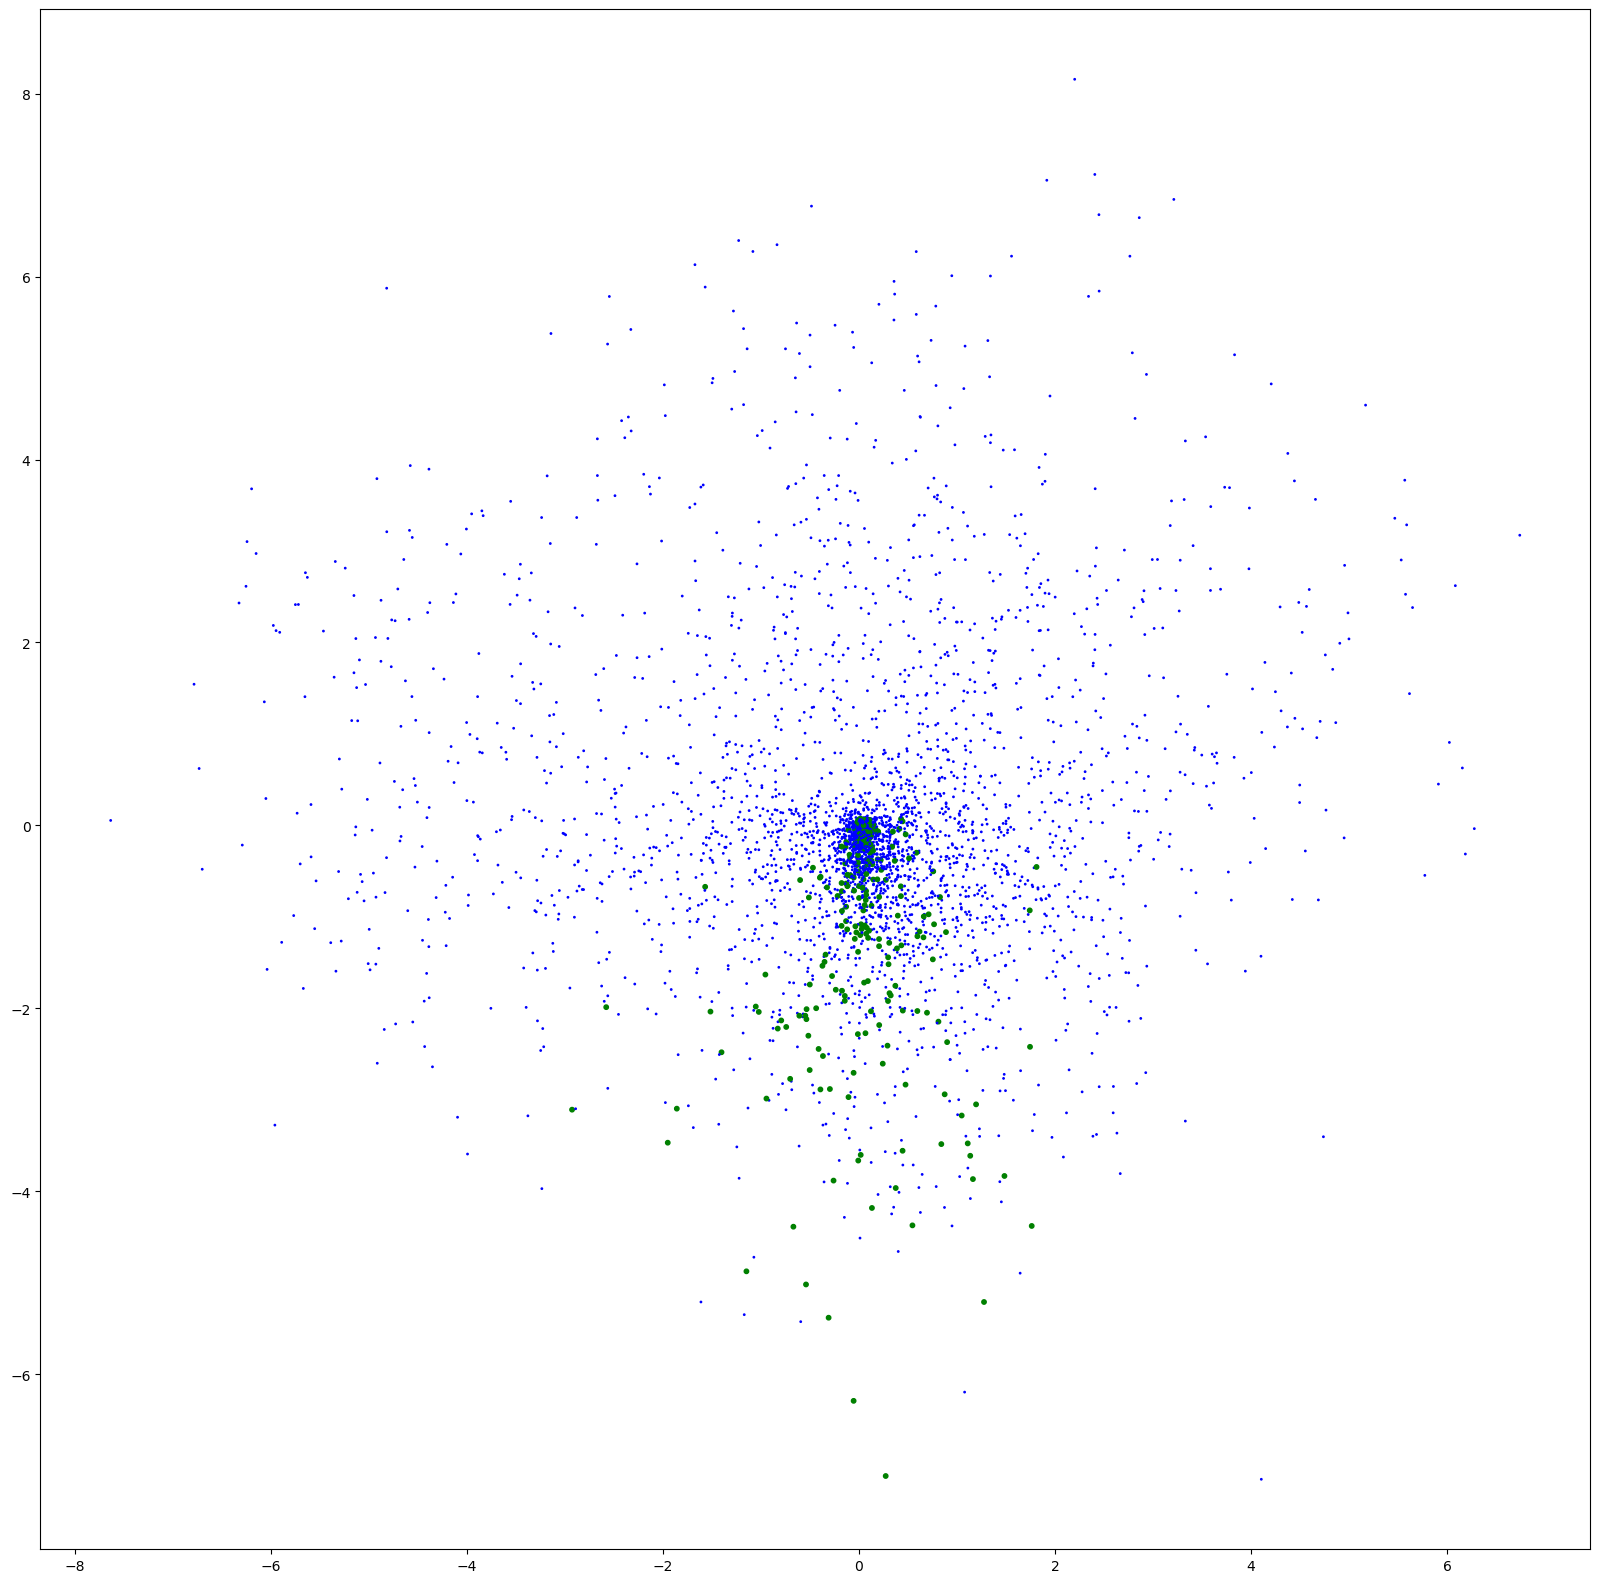

In [44]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,20))
colors = ['b'] * len(product_ids)
s = [1] * len(product_ids)
keywords_list = ['VINTAGE', 'HEART', 'HANGER', 'FRAME', 'SIGN', 'CLOCK', 'CANDLE', 'LIGHT', 'DECORATION', 'ORNAMENT']

for i, pid in enumerate(product_ids):
    description = str(id_to_description.get(pid, '')).upper()
    if any(keyword in description for keyword in keywords_list):
        colors[i] = 'g'
        s[i] = 10

plt.scatter(embeddings_2d[:,0], embeddings_2d[:,1], c=colors, s=s)
plt.show()

# Compute the product similarity

In [45]:
import numpy as np

def calculate_prod_sim(prod1, prod2, model):
  prod1_vec = model.wv[prod1]
  prod2_vec = model.wv[prod2]
  return (prod1_vec @ prod2_vec) / (np.linalg.norm(prod1_vec) * np.linalg.norm(prod2_vec))

In [46]:
calculate_prod_sim(test_sequences[0].split()[0],
                   test_sequences[0].split()[1],
                   model)

np.float32(0.79268533)

In [47]:
prod_sim_result = []
top_n = 5
for test_idx in range(0, len(test_sequences)):
  similar_products = []
  bought_products = test_sequences[test_idx].split()
  for idx in range(0,len(bought_products)):
    if bought_products[idx] in model.wv:
      similar_products = model.wv.most_similar(bought_products[idx], topn = top_n)
      break
  if similar_products != []:
    correct_items = [item[0] for item in similar_products if str(item[0]) in bought_products] # Item[0] is for extracting the stockCode
    prod_sim_result.append(len(correct_items) / top_n)
print("Result:", np.mean(prod_sim_result, axis = 0))

Result: 0.12603335750543873


It's hard to imagin that the score is quite low. So, i try to print out some description to find out if the recommended items are relevant

In [48]:
sample_test_idx = 3
bought_products = test_sequences[sample_test_idx].split()

bought_products_description = []
for item in bought_products:
  if item.isdigit():
    item = int(item)
  bought_products_description.append(id_to_description.get(item, 'Unknown'))

print("Expected products:\n", bought_products_description)

for idx in range(0,len(bought_products)):
    if bought_products[idx] in model.wv:
      similar_products = model.wv.most_similar(bought_products[idx], topn = top_n)
      if bought_products[idx].isdigit():
        bought_products[idx] = int(bought_products[idx])
      print("Initial product:", id_to_description.get(bought_products[idx], 'Unknown'))
      break
if similar_products != []:
  correct_items = [item[0] for item in similar_products if str(item[0]) in bought_products]
  prod_sim_result.append(len(correct_items) / top_n)
  print("Number of corrected items: ", len(correct_items))


similar_products_description = []
for item in similar_products:
  stockcode = item[0]
  if stockcode.isdigit():
    stockcode = int(stockcode)
  similar_products_description.append(id_to_description.get(stockcode, 'Unknown'))

print("Predicted products:\n", similar_products_description)

Expected products:
 ['DOGGY RUBBER', 'SLEEPING CAT ERASERS', 'EMBROIDERED RIBBON REEL SUSIE ', 'EMBROIDERED RIBBON REEL REBECCA ', 'EMBROIDERED RIBBON REEL RUBY ', 'DRAWER KNOB CRACKLE GLAZE IVORY', 'ANTIQUE SILVER BAUBLE LAMP  ', 'BOX OF 6 CHRISTMAS CAKE DECORATIONS', 'FELTCRAFT CHRISTMAS FAIRY', 'CHRISTMAS CRAFT TREE TOP ANGEL', 'PAPER CHAIN KIT RETROSPOT', 'CHRISTMAS CRAFT LITTLE FRIENDS', 'VINTAGE DOILY TRAVEL SEWING KIT', 'FELTCRAFT CUSHION OWL', 'PINK CREAM FELT CRAFT TRINKET BOX ', "PAPER CHAIN KIT 50'S CHRISTMAS ", 'PAPER CHAIN KIT VINTAGE CHRISTMAS']
Initial product: DOGGY RUBBER
Number of corrected items:  0
Predicted products:
 ['LETTER SHAPE PENCIL SHARPENER', 'SILVER FABRIC MIRROR', 'POPART RECT PENCIL SHARPENER ASST', 'ANIMAL STICKERS', 'GOLD FABRIC MIRROR']


As shown in this example, even though the recommender give quite good products. But, it seems like the performance is low due to the specific-index problem, and the short context it get.

# Recommondation system from user's history

For simplicity, I just need to get the most relevance item of each item in the history list. Then i sort to show. But, i think this method will reduce huge amount of diversity. But, it work pretty ok, i think

In [49]:
def recommend_products_for_user(user_history_str, model, n_rec=5):
    list_rcm_items = []
    for item in user_history_str.split():
        if item in model.wv:
            # Get the top 1 similar product
            rcm_item = model.wv.most_similar(item, topn=1)[0]
            pid, score = rcm_item

            # Convert StockCode to int if numeric
            if str(pid).isdigit():
                processed_pid = int(pid)
            else:
                processed_pid = pid

            list_rcm_items.append((processed_pid, score))

    recommendations = sorted(list_rcm_items, key=lambda x: x[1], reverse=True)

    if len(recommendations) > n_rec:
        return recommendations[:n_rec]

    return recommendations

# Test on a sample from the test set
results = []
for idx in range(0, len(test_sequences)):
  test_sample = test_sequences[idx]
  test_sample_list = test_sample.split()
  n_rec = 10
  recs = recommend_products_for_user(test_sample, model, n_rec)


  # print(f"User History (First 5): {test_sample.split()[:5]}")
  # print("\nRecommended Products (Sorted by Similarity):")
  total = 0
  for pid, score in recs:
      description = id_to_description.get(pid, 'Unknown')
      # print(f"{pid}: {description} (Score: {score:.3f})")
      if str(pid) in test_sample_list:
          total += 1
  # print(f"\nTotal number of products predicted correctly: {total}/{n_rec}")
  result = total / n_rec
  results.append(result)
print(np.mean(results))


0.2960841189267585


# Conclusion

As shown in some example above, even though the recommender give quite good products. But, it seems like the performance is low due to the specific-index problem, and the short context it get. The future work is to try out some metrics that better represent the similarity of the recommendation and the expected products.